In [16]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

PARQUET_DIR = os.path.expanduser('~/kkbox-churn/data/parquet/')
con = duckdb.connect()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Ready.")

Ready.


In [17]:
txn_stats = con.execute(f"""
    SELECT
        COUNT(*)                        AS total_transactions,
        COUNT(DISTINCT msno)            AS unique_users,
        AVG(payment_plan_days)          AS avg_plan_days,
        MIN(payment_plan_days)          AS min_plan_days,
        MAX(payment_plan_days)          AS max_plan_days,
        AVG(actual_amount_paid)         AS avg_amount,
        MIN(actual_amount_paid)         AS min_amount,
        MAX(actual_amount_paid)         AS max_amount,
        AVG(is_auto_renew)              AS auto_renew_rate,
        AVG(is_cancel)                  AS cancel_rate
    FROM (
        SELECT * FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
    )
""").df()

print("=== TRANSACTION SUMMARY ===")
print(txn_stats.T)

=== TRANSACTION SUMMARY ===
                               0
total_transactions  2.297876e+07
unique_users        2.426143e+06
avg_plan_days       3.349869e+01
min_plan_days       0.000000e+00
max_plan_days       4.500000e+02
avg_amount          1.506641e+02
min_amount          0.000000e+00
max_amount          2.000000e+03
auto_renew_rate     8.478146e-01
cancel_rate         3.881777e-02


In [18]:
# Plan days = 0
zero_plan = con.execute(f"""
    SELECT 
        payment_plan_days,
        COUNT(*) AS count,
        AVG(actual_amount_paid) AS avg_amount,
        AVG(is_cancel) AS cancel_rate
    FROM (
        SELECT * FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
    )
    WHERE payment_plan_days <= 1
    GROUP BY payment_plan_days
    ORDER BY payment_plan_days
""").df()

print("=== ZERO/ONE DAY PLANS ===")
print(zero_plan)

# Amount paid = 0
zero_amount = con.execute(f"""
    SELECT 
        COUNT(*) AS count,
        AVG(is_cancel) AS cancel_rate,
        AVG(is_auto_renew) AS auto_renew_rate
    FROM (
        SELECT * FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
    )
    WHERE actual_amount_paid = 0
""").df()

print("\n=== ZERO AMOUNT TRANSACTIONS ===")
print(zero_amount)

=== ZERO/ONE DAY PLANS ===
   payment_plan_days   count  avg_amount  cancel_rate
0                  0  872342  157.684237      0.02087
1                  1    5435    0.000000      0.00000

=== ZERO AMOUNT TRANSACTIONS ===
     count  cancel_rate  auto_renew_rate
0  1218324     0.202543         0.470592


In [19]:
plan_summary = con.execute(f"""
    SELECT 
        CASE 
            WHEN payment_plan_days = 0 THEN 'zero days'
            WHEN payment_plan_days = 1 THEN 'one day'
            WHEN payment_plan_days = 30 THEN '30 days'
            WHEN payment_plan_days = 90 THEN '90 days'
            WHEN payment_plan_days = 180 THEN '180 days'
            WHEN payment_plan_days = 365 THEN '365 days'
            ELSE 'other'
        END AS plan_type,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM (
        SELECT * FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
    )
    GROUP BY plan_type
    ORDER BY count DESC
""").df()

print(plan_summary)

   plan_type     count    pct
0    30 days  20174288  87.80
1      other   1814928   7.90
2  zero days    872342   3.80
3   180 days     76172   0.33
4    90 days     31440   0.14
5    one day      5435   0.02
6   365 days      4150   0.02


   payment_plan_days     count  churn_rate
0                 30  15057805    0.063150
1                 31    463142    0.061655
2                  7     45282    0.345612
3                195     29324    0.549413
4                410     20305    0.634622
5                180     13651    0.833639
6                 90     10273    0.581622
7                100      7469    0.567278
8                 10      4532    0.562224
9                 60      4526    0.568493


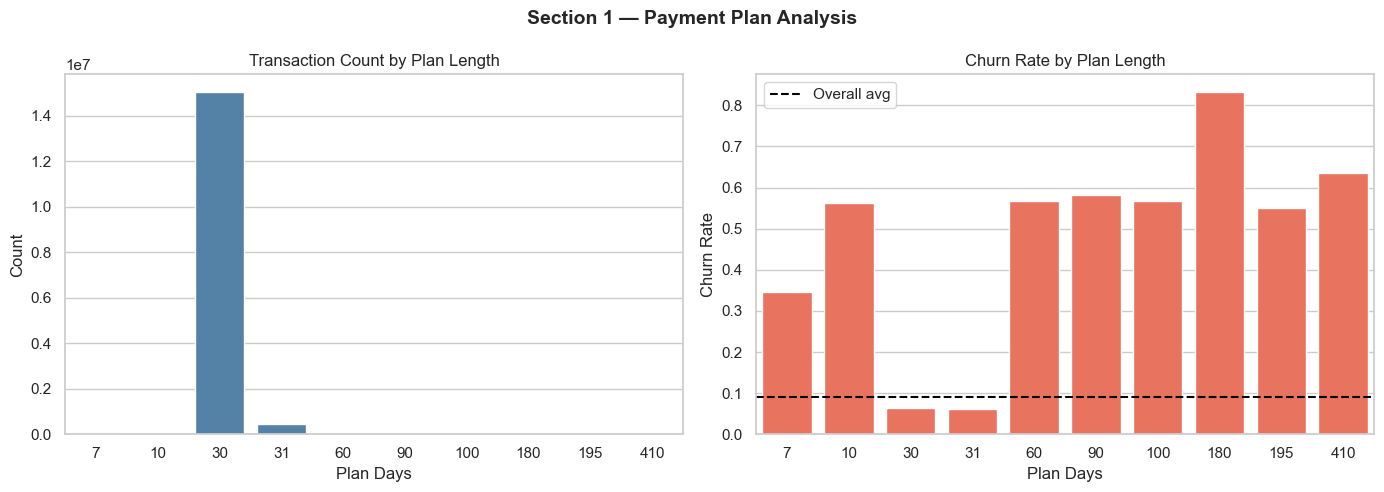

In [20]:
plan_dist = con.execute(f"""
    SELECT 
        payment_plan_days,
        COUNT(*) AS count,
        AVG(is_churn) AS churn_rate
    FROM (
        SELECT * FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
    ) t
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON t.msno = l.msno
    WHERE payment_plan_days > 1
    GROUP BY payment_plan_days
    ORDER BY count DESC
    LIMIT 10
""").df()

print(plan_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plan_dist, x='payment_plan_days', y='count',
            color='steelblue', ax=axes[0])
axes[0].set_title('Transaction Count by Plan Length')
axes[0].set_xlabel('Plan Days')
axes[0].set_ylabel('Count')

sns.barplot(data=plan_dist, x='payment_plan_days', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Plan Length')
axes[1].set_xlabel('Plan Days')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 1 — Payment Plan Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

   is_auto_renew  total_users  churn_rate
0              0       185447    0.248218
1              1       871590    0.051907

=== CURRENT AUTO RENEW STATUS ===
   current_auto_renew  total_users  churn_rate
0                   0       113621    0.426444
1                   1       857328    0.045335


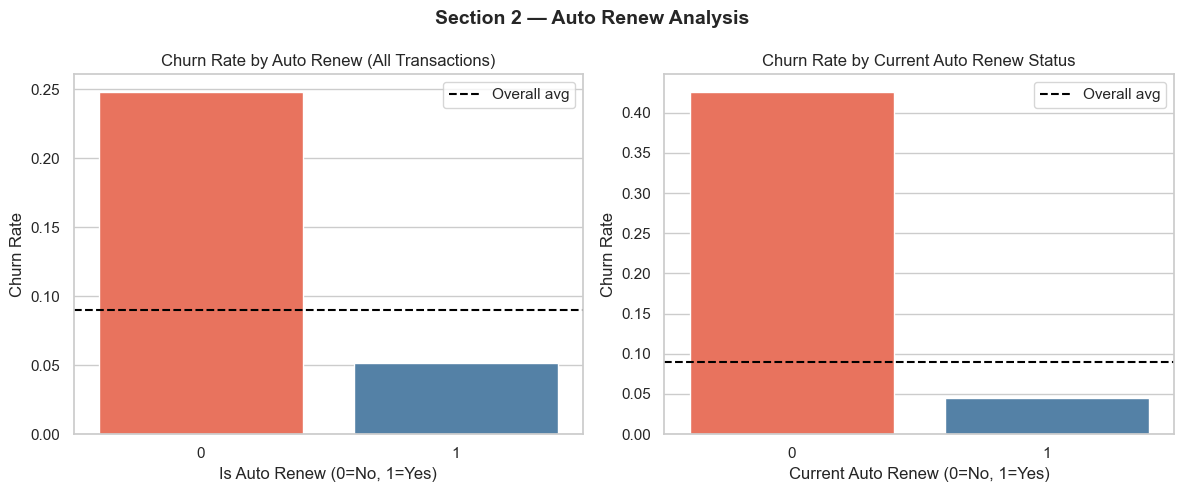

In [21]:
autorenew_churn = con.execute(f"""
    SELECT 
        t.is_auto_renew,
        COUNT(DISTINCT t.msno)      AS total_users,
        AVG(l.is_churn)             AS churn_rate
    FROM (
        SELECT * FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
    ) t
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON t.msno = l.msno
    WHERE payment_plan_days > 1
    GROUP BY t.is_auto_renew
    ORDER BY t.is_auto_renew
""").df()

print(autorenew_churn)

# Most recent auto renew status per user
recent_autorenew = con.execute(f"""
    WITH ranked AS (
        SELECT 
            msno,
            is_auto_renew,
            ROW_NUMBER() OVER (
                PARTITION BY msno 
                ORDER BY transaction_date DESC
            ) AS rn
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
    )
    SELECT 
        r.is_auto_renew AS current_auto_renew,
        COUNT(DISTINCT r.msno) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM ranked r
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON r.msno = l.msno
    WHERE r.rn = 1
    GROUP BY r.is_auto_renew
    ORDER BY r.is_auto_renew
""").df()

print("\n=== CURRENT AUTO RENEW STATUS ===")
print(recent_autorenew)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=autorenew_churn, x='is_auto_renew', y='churn_rate',
            palette=['tomato', 'steelblue'], ax=axes[0])
axes[0].set_title('Churn Rate by Auto Renew (All Transactions)')
axes[0].set_xlabel('Is Auto Renew (0=No, 1=Yes)')
axes[0].set_ylabel('Churn Rate')
axes[0].axhline(y=0.0899, color='black', linestyle='--', label='Overall avg')
axes[0].legend()

sns.barplot(data=recent_autorenew, x='current_auto_renew', y='churn_rate',
            palette=['tomato', 'steelblue'], ax=axes[1])
axes[1].set_title('Churn Rate by Current Auto Renew Status')
axes[1].set_xlabel('Current Auto Renew (0=No, 1=Yes)')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black', linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 2 — Auto Renew Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

        cancel_group  total_users  churn_rate
0  3-5 cancellations         7923    0.213429
1    2 cancellations        35302    0.184352
2   6+ cancellations          174    0.172414
3     1 cancellation       178737    0.160862
4    0 cancellations       748813    0.067225


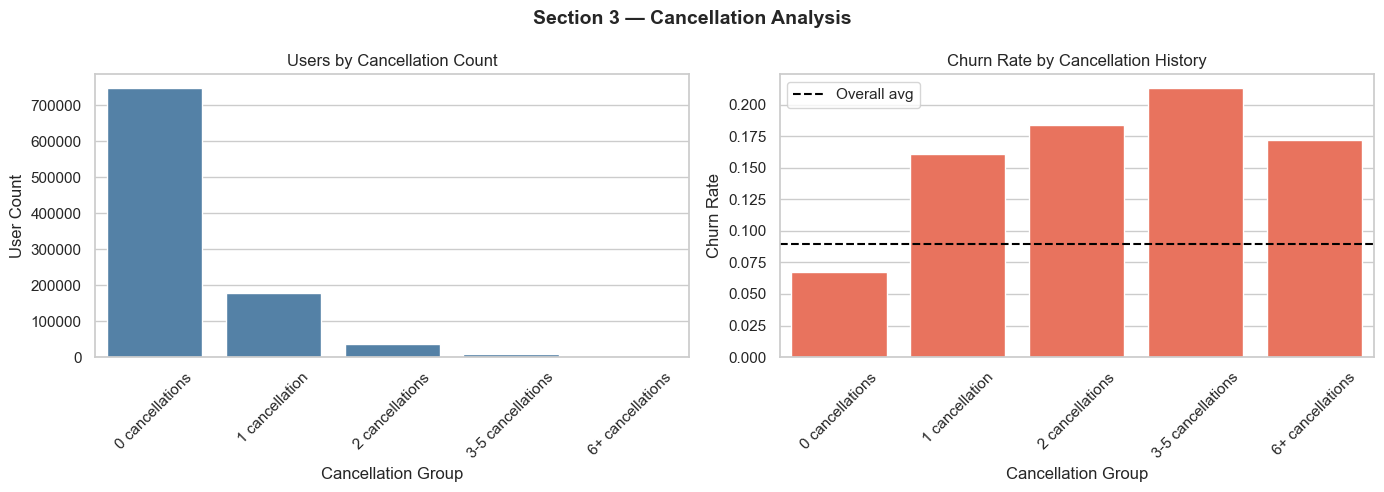

In [22]:
# Cancellation distribution
cancel_dist = con.execute(f"""
    WITH user_cancels AS (
        SELECT 
            msno,
            SUM(is_cancel) AS total_cancellations
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT 
        CASE 
            WHEN total_cancellations = 0 THEN '0 cancellations'
            WHEN total_cancellations = 1 THEN '1 cancellation'
            WHEN total_cancellations = 2 THEN '2 cancellations'
            WHEN total_cancellations BETWEEN 3 AND 5 THEN '3-5 cancellations'
            ELSE '6+ cancellations'
        END AS cancel_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_cancels u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY cancel_group
    ORDER BY churn_rate DESC
""").df()

print(cancel_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['0 cancellations', '1 cancellation', '2 cancellations',
         '3-5 cancellations', '6+ cancellations']
cancel_ordered = cancel_dist.set_index('cancel_group')\
                            .reindex(order).reset_index().dropna()

sns.barplot(data=cancel_ordered, x='cancel_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Cancellation Count')
axes[0].set_xlabel('Cancellation Group')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=cancel_ordered, x='cancel_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Cancellation History')
axes[1].set_xlabel('Cancellation Group')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 3 — Cancellation Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== TOP 10 PAYMENT METHODS ===
   payment_method_id  total_users  churn_rate
0                 41       544626    0.039400
1                 40        73891    0.063986
2                 36        73857    0.133095
3                 39        66304    0.060524
4                 38        58314    0.361320
5                 37        37046    0.029747
6                 34        28717    0.019222
7                 29        18368    0.187282
8                 30        17117    0.134895
9                 33        14169    0.035782

=== DISCOUNT ANALYSIS ===
   has_discount  total_users  churn_rate
0             0       886512    0.088016
1             1        84437    0.110058


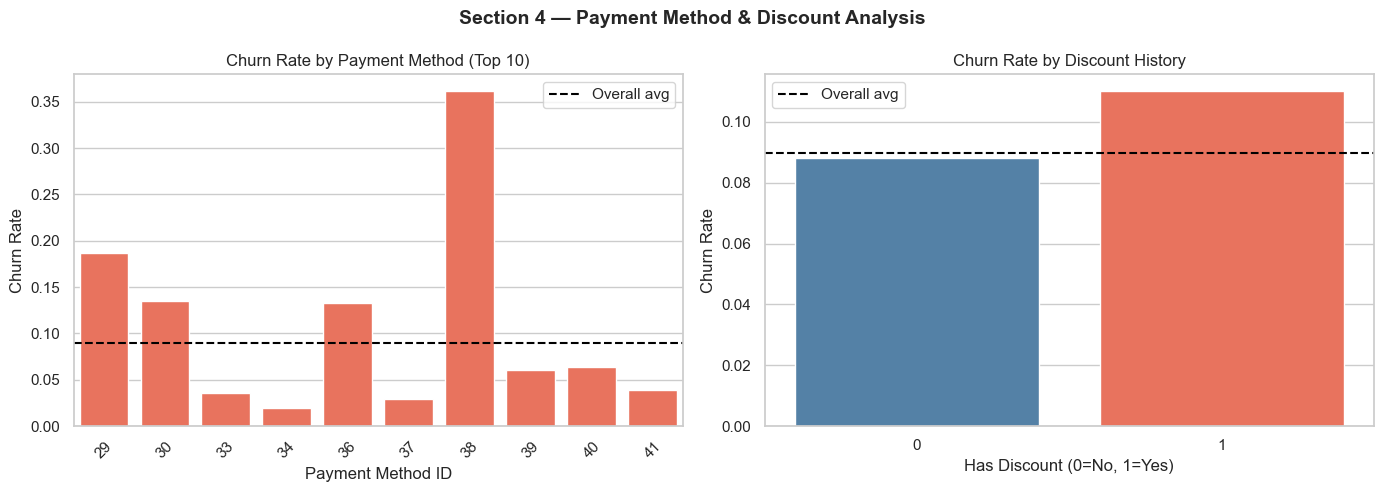

In [23]:
# Payment method analysis
payment_churn = con.execute(f"""
    WITH latest_payment AS (
        SELECT 
            msno,
            payment_method_id,
            ROW_NUMBER() OVER (
                PARTITION BY msno 
                ORDER BY transaction_date DESC
            ) AS rn
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
    )
    SELECT 
        p.payment_method_id,
        COUNT(DISTINCT p.msno)  AS total_users,
        AVG(l.is_churn)         AS churn_rate
    FROM latest_payment p
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON p.msno = l.msno
    WHERE p.rn = 1
    GROUP BY p.payment_method_id
    ORDER BY total_users DESC
    LIMIT 10
""").df()

print("=== TOP 10 PAYMENT METHODS ===")
print(payment_churn)

# Discount analysis
discount_churn = con.execute(f"""
    WITH user_discount AS (
        SELECT 
            msno,
            SUM(plan_list_price - actual_amount_paid)   AS total_discount,
            AVG(plan_list_price - actual_amount_paid)   AS avg_discount,
            CASE WHEN SUM(plan_list_price - 
                actual_amount_paid) > 0 
                THEN 1 ELSE 0 END                       AS has_discount
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT 
        has_discount,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_discount u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY has_discount
    ORDER BY has_discount
""").df()

print("\n=== DISCOUNT ANALYSIS ===")
print(discount_churn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=payment_churn, x='payment_method_id', y='churn_rate',
            color='tomato', ax=axes[0])
axes[0].set_title('Churn Rate by Payment Method (Top 10)')
axes[0].set_xlabel('Payment Method ID')
axes[0].set_ylabel('Churn Rate')
axes[0].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=discount_churn, x='has_discount', y='churn_rate',
            palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Churn Rate by Discount History')
axes[1].set_xlabel('Has Discount (0=No, 1=Yes)')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 4 — Payment Method & Discount Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  recency_group  total_users  churn_rate
0      0-7 days       937619    0.061714
1     8-30 days        20400    0.852108
2    31-60 days         1738    0.884925
3    61-90 days         1679    0.921977
4      90+ days         9513    0.944707


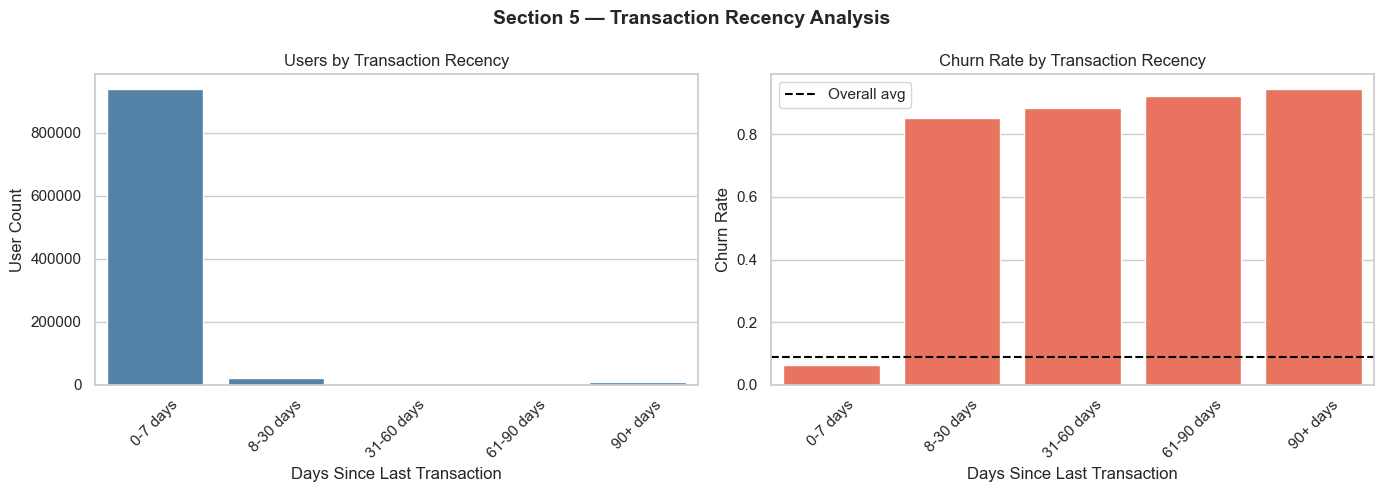

In [24]:
recency_churn = con.execute(f"""
    WITH user_recency AS (
        SELECT 
            msno,
            DATEDIFF('day',
                STRPTIME(CAST(MAX(transaction_date) AS VARCHAR), '%Y%m%d'),
                DATE '2017-03-01') AS days_since_last_txn,
            DATEDIFF('day',
                STRPTIME(CAST(MAX(membership_expire_date) AS VARCHAR), '%Y%m%d'),
                DATE '2017-03-01') AS days_to_expiry
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT 
        CASE 
            WHEN days_since_last_txn <= 7   THEN '0-7 days'
            WHEN days_since_last_txn <= 30  THEN '8-30 days'
            WHEN days_since_last_txn <= 60  THEN '31-60 days'
            WHEN days_since_last_txn <= 90  THEN '61-90 days'
            ELSE '90+ days'
        END AS recency_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_recency u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY recency_group
    ORDER BY churn_rate ASC
""").df()

print(recency_churn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['0-7 days', '8-30 days', '31-60 days', '61-90 days', '90+ days']
recency_ordered = recency_churn.set_index('recency_group')\
                               .reindex(order).reset_index().dropna()

sns.barplot(data=recency_ordered, x='recency_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Transaction Recency')
axes[0].set_xlabel('Days Since Last Transaction')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=recency_ordered, x='recency_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Transaction Recency')
axes[1].set_xlabel('Days Since Last Transaction')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 5 — Transaction Recency Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

      expiry_group  total_users  churn_rate
0         0-7 days         9938    0.970417
1         90+ days        29072    0.816387
2  already expired            9    0.777778
3        8-30 days        47755    0.649314
4       61-90 days        80245    0.054010
5       31-60 days       803930    0.023128


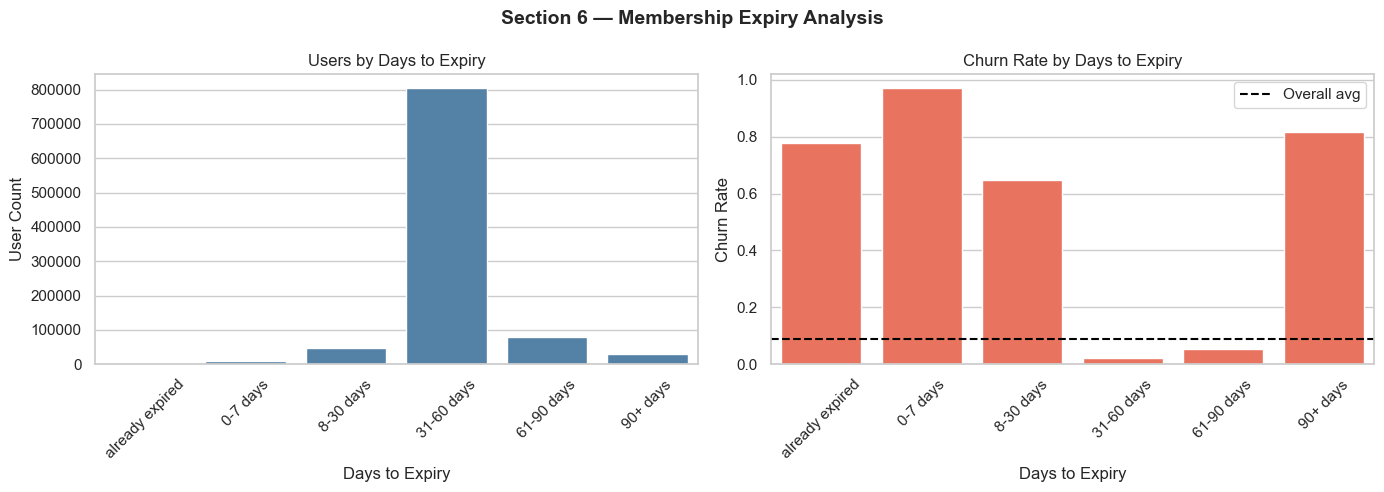

In [25]:
expiry_churn = con.execute(f"""
    WITH user_expiry AS (
        SELECT 
            msno,
            DATEDIFF('day',
                DATE '2017-03-01',
                STRPTIME(CAST(MAX(membership_expire_date) AS VARCHAR), '%Y%m%d')
            ) AS days_to_expiry
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT 
        CASE 
            WHEN days_to_expiry < 0    THEN 'already expired'
            WHEN days_to_expiry <= 7   THEN '0-7 days'
            WHEN days_to_expiry <= 30  THEN '8-30 days'
            WHEN days_to_expiry <= 60  THEN '31-60 days'
            WHEN days_to_expiry <= 90  THEN '61-90 days'
            ELSE '90+ days'
        END AS expiry_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_expiry u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY expiry_group
    ORDER BY churn_rate DESC
""").df()

print(expiry_churn)

order = ['already expired', '0-7 days', '8-30 days',
         '31-60 days', '61-90 days', '90+ days']
expiry_ordered = expiry_churn.set_index('expiry_group')\
                             .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=expiry_ordered, x='expiry_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Days to Expiry')
axes[0].set_xlabel('Days to Expiry')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=expiry_ordered, x='expiry_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Days to Expiry')
axes[1].set_xlabel('Days to Expiry')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 6 — Membership Expiry Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

          freq_group  total_users  churn_rate  avg_tenure_days
0      1 transaction         7686    0.838538         0.000000
1   2-3 transactions        64410    0.241764        98.678932
2   4-6 transactions        87760    0.141477       190.280754
3  7-12 transactions       175043    0.077615       314.907006
4   13+ transactions       636050    0.061789       640.452637


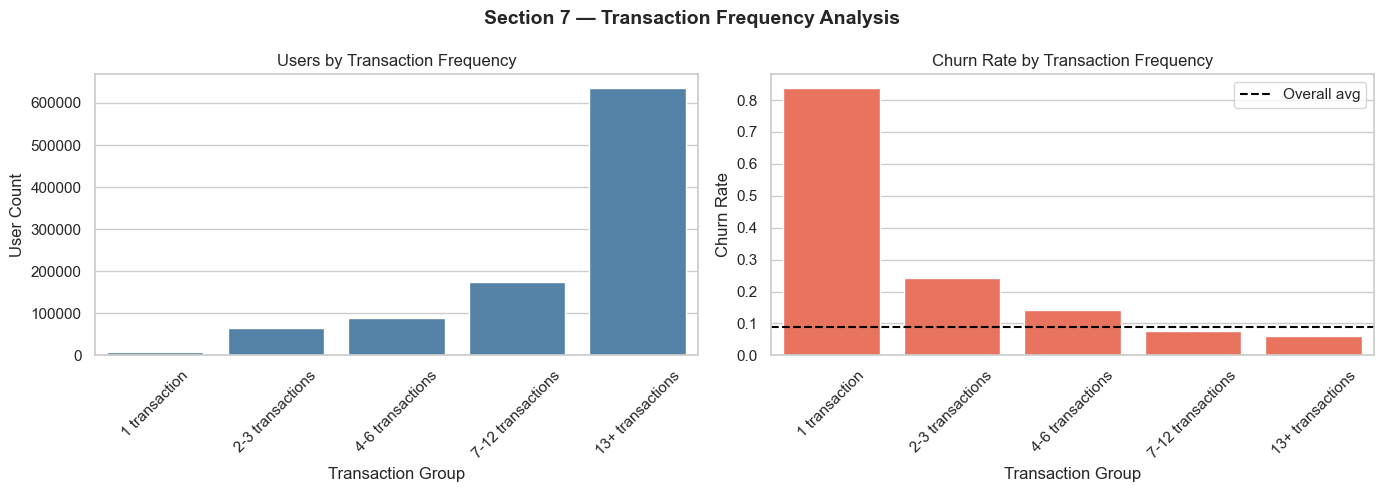

In [26]:
freq_churn = con.execute(f"""
    WITH user_freq AS (
        SELECT 
            msno,
            COUNT(*) AS total_transactions,
            COUNT(DISTINCT 
                SUBSTR(CAST(transaction_date AS VARCHAR), 1, 6)
            ) AS active_months,
            DATEDIFF('day',
                STRPTIME(CAST(MIN(transaction_date) AS VARCHAR), '%Y%m%d'),
                STRPTIME(CAST(MAX(transaction_date) AS VARCHAR), '%Y%m%d')
            ) AS customer_tenure_days
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT 
        CASE 
            WHEN total_transactions = 1  THEN '1 transaction'
            WHEN total_transactions <= 3 THEN '2-3 transactions'
            WHEN total_transactions <= 6 THEN '4-6 transactions'
            WHEN total_transactions <= 12 THEN '7-12 transactions'
            ELSE '13+ transactions'
        END AS freq_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate,
        AVG(customer_tenure_days) AS avg_tenure_days
    FROM user_freq u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY freq_group
    ORDER BY churn_rate DESC
""").df()

print(freq_churn)

order = ['1 transaction', '2-3 transactions', '4-6 transactions',
         '7-12 transactions', '13+ transactions']
freq_ordered = freq_churn.set_index('freq_group')\
                         .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=freq_ordered, x='freq_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Transaction Frequency')
axes[0].set_xlabel('Transaction Group')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=freq_ordered, x='freq_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Transaction Frequency')
axes[1].set_xlabel('Transaction Group')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 7 — Transaction Frequency Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

       price_trend  total_users  churn_rate  avg_price_range
0  price increased        98224    0.205052       177.626771
1  price decreased        98987    0.082708       210.452383
2  price unchanged       773159    0.075580         7.745341


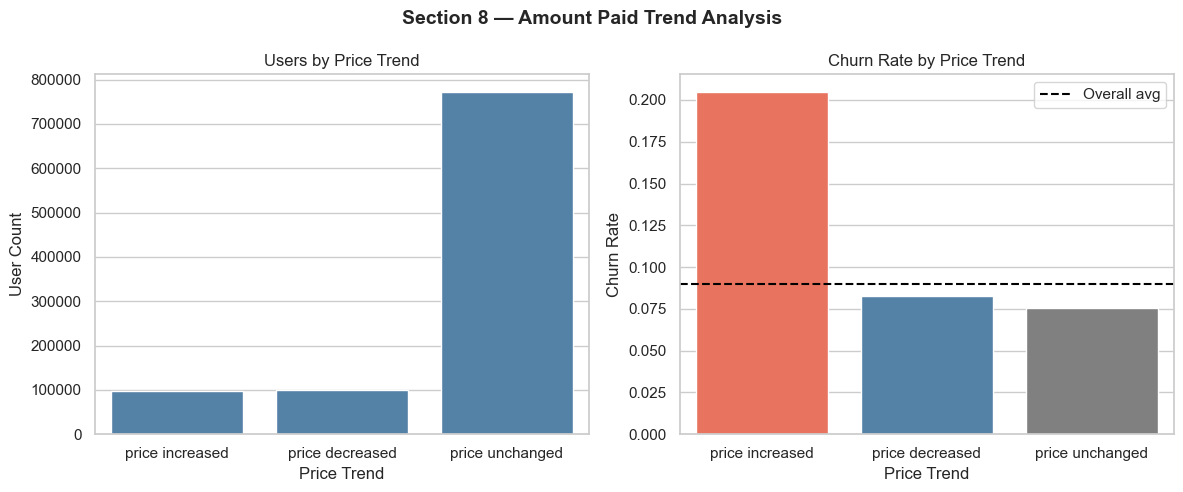

In [27]:
amount_trend = con.execute(f"""
    WITH user_amounts AS (
        SELECT 
            msno,
            MAX(actual_amount_paid)     AS max_amount,
            MIN(actual_amount_paid)     AS min_amount,
            AVG(actual_amount_paid)     AS avg_amount,
            LAST(actual_amount_paid 
                ORDER BY transaction_date) AS last_amount,
            FIRST(actual_amount_paid 
                ORDER BY transaction_date) AS first_amount,
            MAX(actual_amount_paid) - 
                MIN(actual_amount_paid) AS price_range
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        AND actual_amount_paid > 0
        GROUP BY msno
    )
    SELECT
        CASE
            WHEN last_amount > first_amount THEN 'price increased'
            WHEN last_amount < first_amount THEN 'price decreased'
            ELSE 'price unchanged'
        END AS price_trend,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate,
        AVG(price_range) AS avg_price_range
    FROM user_amounts u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY price_trend
    ORDER BY churn_rate DESC
""").df()

print(amount_trend)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=amount_trend, x='price_trend', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Price Trend')
axes[0].set_xlabel('Price Trend')
axes[0].set_ylabel('User Count')

sns.barplot(data=amount_trend, x='price_trend', y='churn_rate',
            palette=['tomato', 'steelblue', 'gray'], ax=axes[1])
axes[1].set_title('Churn Rate by Price Trend')
axes[1].set_xlabel('Price Trend')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 8 — Amount Paid Trend Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  switch_behavior  total_users  churn_rate
0    switched OFF        10717    0.489689
1      always OFF       102940    0.419963
2     switched ON        51776    0.078994
3       always ON       805516    0.043141


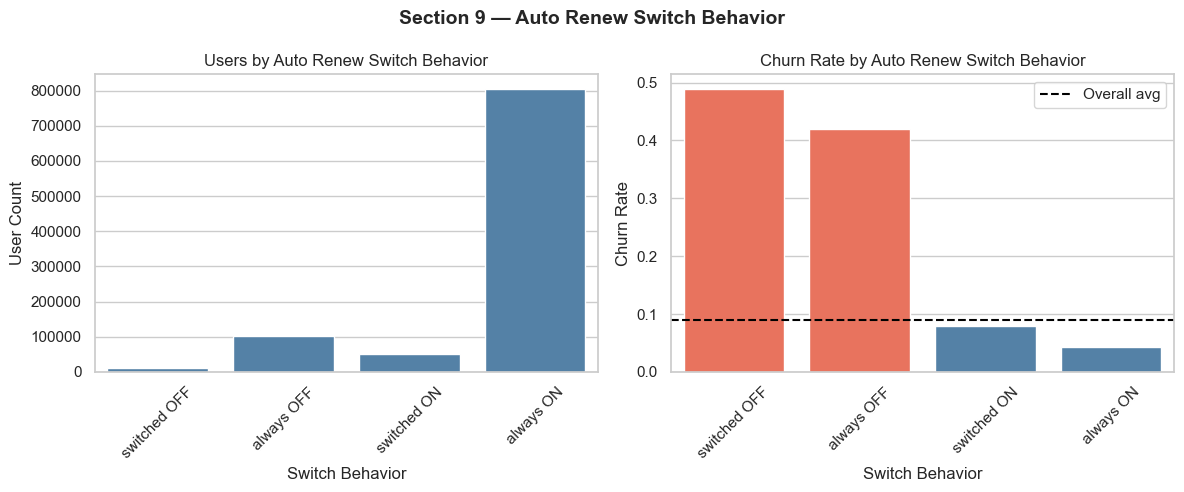

In [28]:
autorenew_switch = con.execute(f"""
    WITH user_autorenew AS (
        SELECT
            msno,
            FIRST(is_auto_renew ORDER BY transaction_date ASC)  AS first_auto_renew,
            LAST(is_auto_renew ORDER BY transaction_date ASC)   AS last_auto_renew,
            SUM(CASE WHEN is_auto_renew = 0 THEN 1 ELSE 0 END)  AS times_turned_off,
            SUM(CASE WHEN is_auto_renew = 1 THEN 1 ELSE 0 END)  AS times_turned_on
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT
        CASE
            WHEN first_auto_renew = 1 
                AND last_auto_renew = 0 THEN 'switched OFF'
            WHEN first_auto_renew = 0 
                AND last_auto_renew = 1 THEN 'switched ON'
            WHEN first_auto_renew = 1 
                AND last_auto_renew = 1 THEN 'always ON'
            WHEN first_auto_renew = 0 
                AND last_auto_renew = 0 THEN 'always OFF'
        END AS switch_behavior,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_autorenew u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY switch_behavior
    ORDER BY churn_rate DESC
""").df()

print(autorenew_switch)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=autorenew_switch, x='switch_behavior', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Auto Renew Switch Behavior')
axes[0].set_xlabel('Switch Behavior')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=autorenew_switch, x='switch_behavior', y='churn_rate',
            palette=['tomato','tomato','steelblue','steelblue'], ax=axes[1])
axes[1].set_title('Churn Rate by Auto Renew Switch Behavior')
axes[1].set_xlabel('Switch Behavior')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 9 — Auto Renew Switch Behavior',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

      cancel_recency_group  total_users  churn_rate
0   cancelled last 30 days        48695    0.526769
1   cancelled last 90 days        20573    0.073251
2          never cancelled       748813    0.067225
3  cancelled 180+ days ago       125457    0.065034
4  cancelled last 180 days        27411    0.060706


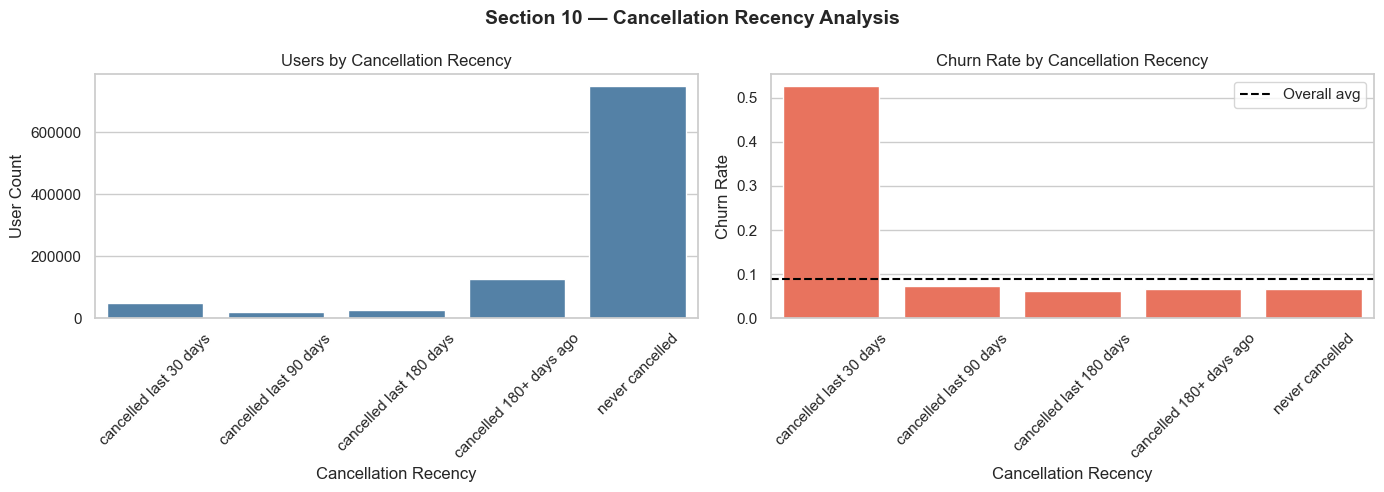

In [29]:
cancel_recency = con.execute(f"""
    WITH user_cancel_recency AS (
        SELECT
            msno,
            MAX(CASE WHEN is_cancel = 1 
                THEN transaction_date ELSE NULL END) AS last_cancel_date,
            SUM(is_cancel) AS total_cancellations
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT
        CASE
            WHEN last_cancel_date IS NULL THEN 'never cancelled'
            WHEN DATEDIFF('day',
                STRPTIME(CAST(last_cancel_date AS VARCHAR), '%Y%m%d'),
                DATE '2017-03-01') <= 30  THEN 'cancelled last 30 days'
            WHEN DATEDIFF('day',
                STRPTIME(CAST(last_cancel_date AS VARCHAR), '%Y%m%d'),
                DATE '2017-03-01') <= 90  THEN 'cancelled last 90 days'
            WHEN DATEDIFF('day',
                STRPTIME(CAST(last_cancel_date AS VARCHAR), '%Y%m%d'),
                DATE '2017-03-01') <= 180 THEN 'cancelled last 180 days'
            ELSE 'cancelled 180+ days ago'
        END AS cancel_recency_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_cancel_recency u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY cancel_recency_group
    ORDER BY churn_rate DESC
""").df()

print(cancel_recency)

order = ['cancelled last 30 days', 'cancelled last 90 days',
         'cancelled last 180 days', 'cancelled 180+ days ago',
         'never cancelled']
cancel_rec_ordered = cancel_recency.set_index('cancel_recency_group')\
                                   .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=cancel_rec_ordered, x='cancel_recency_group',
            y='total_users', color='steelblue', ax=axes[0])
axes[0].set_title('Users by Cancellation Recency')
axes[0].set_xlabel('Cancellation Recency')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=cancel_rec_ordered, x='cancel_recency_group',
            y='churn_rate', color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Cancellation Recency')
axes[1].set_xlabel('Cancellation Recency')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 10 — Cancellation Recency Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  payment_change_group  total_users  churn_rate
0     changed 3+ times         5616    0.302528
1        changed twice        27416    0.234717
2         changed once       109936    0.200398
3        never changed       827981    0.069029


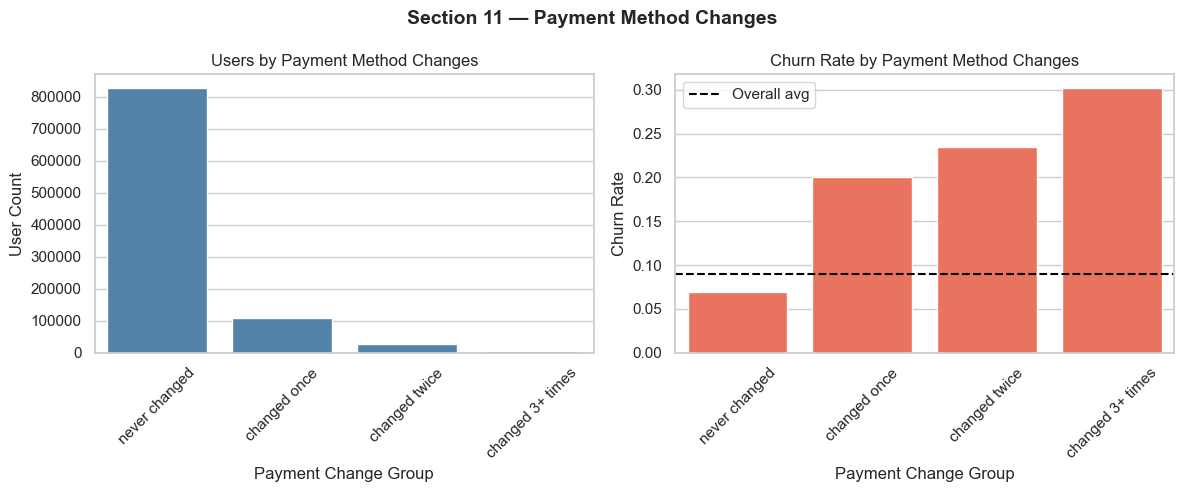

In [30]:
payment_method_changes = con.execute(f"""
    WITH user_payment AS (
        SELECT
            msno,
            COUNT(DISTINCT payment_method_id)   AS unique_payment_methods,
            FIRST(payment_method_id 
                ORDER BY transaction_date ASC)  AS first_payment_method,
            LAST(payment_method_id 
                ORDER BY transaction_date ASC)  AS last_payment_method
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT
        CASE
            WHEN unique_payment_methods = 1 THEN 'never changed'
            WHEN unique_payment_methods = 2 THEN 'changed once'
            WHEN unique_payment_methods = 3 THEN 'changed twice'
            ELSE 'changed 3+ times'
        END AS payment_change_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate
    FROM user_payment u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY payment_change_group
    ORDER BY churn_rate DESC
""").df()

print(payment_method_changes)

order = ['never changed', 'changed once',
         'changed twice', 'changed 3+ times']
pm_ordered = payment_method_changes.set_index('payment_change_group')\
                                   .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=pm_ordered, x='payment_change_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Payment Method Changes')
axes[0].set_xlabel('Payment Change Group')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=pm_ordered, x='payment_change_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Payment Method Changes')
axes[1].set_xlabel('Payment Change Group')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 11 — Payment Method Changes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  txn_freq_group  total_users  churn_rate  avg_txn_per_month
0   3+ per month          340    0.850000          12.531069
1  2-3 per month         1398    0.708870           2.650698
2  1-2 per month       245054    0.150877           1.141998
3    1 per month       724157    0.067757           1.000000


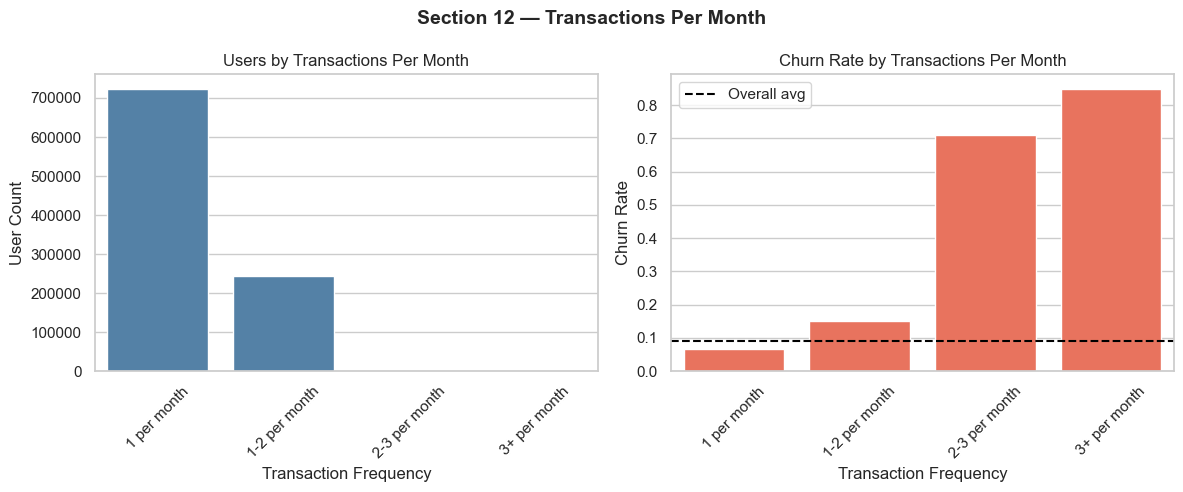

In [31]:
txn_per_month = con.execute(f"""
    WITH user_monthly AS (
        SELECT
            msno,
            COUNT(*) AS total_transactions,
            COUNT(DISTINCT 
                SUBSTR(CAST(transaction_date AS VARCHAR), 1, 6)
            ) AS active_months,
            COUNT(*) * 1.0 / NULLIF(
                COUNT(DISTINCT 
                    SUBSTR(CAST(transaction_date AS VARCHAR), 1, 6)
                ), 0
            ) AS txn_per_month
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
        GROUP BY msno
    )
    SELECT
        CASE
            WHEN txn_per_month <= 1.0 THEN '1 per month'
            WHEN txn_per_month <= 2.0 THEN '1-2 per month'
            WHEN txn_per_month <= 3.0 THEN '2-3 per month'
            ELSE '3+ per month'
        END AS txn_freq_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate,
        AVG(txn_per_month) AS avg_txn_per_month
    FROM user_monthly u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY txn_freq_group
    ORDER BY churn_rate DESC
""").df()

print(txn_per_month)

order = ['1 per month', '1-2 per month', '2-3 per month', '3+ per month']
txn_ordered = txn_per_month.set_index('txn_freq_group')\
                           .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=txn_ordered, x='txn_freq_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Transactions Per Month')
axes[0].set_xlabel('Transaction Frequency')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=txn_ordered, x='txn_freq_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Transactions Per Month')
axes[1].set_xlabel('Transaction Frequency')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 12 — Transactions Per Month',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

     ppd_group  total_users  churn_rate   avg_ppd
0  6-8 per day            1    1.000000  7.000000
1  0-2 per day           14    1.000000  0.011111
2      no data          590    0.961017       NaN
3  4-6 per day       609021    0.118457  4.959026
4  2-4 per day       361334    0.040420  3.334974


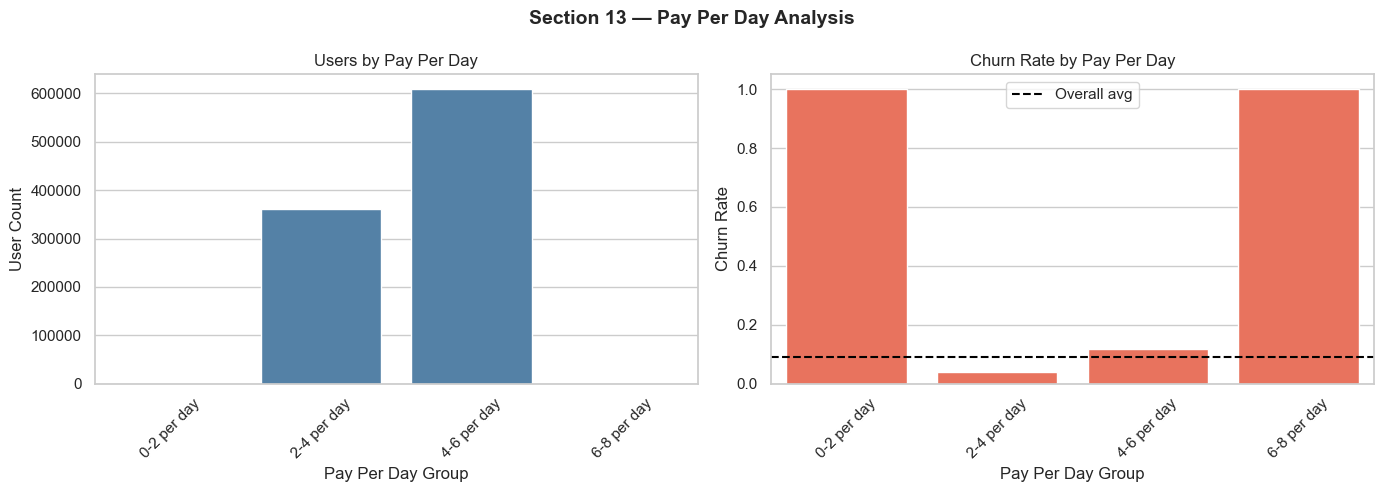

In [32]:
pay_per_day = con.execute(f"""
    WITH user_ppd AS (
        SELECT
            msno,
            AVG(CASE WHEN payment_plan_days > 1 
                AND actual_amount_paid > 0
                THEN actual_amount_paid * 1.0 / payment_plan_days
                ELSE NULL END) AS avg_pay_per_day
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        GROUP BY msno
    )
    SELECT
        CASE
            WHEN avg_pay_per_day IS NULL    THEN 'no data'
            WHEN avg_pay_per_day <= 2       THEN '0-2 per day'
            WHEN avg_pay_per_day <= 4       THEN '2-4 per day'
            WHEN avg_pay_per_day <= 6       THEN '4-6 per day'
            WHEN avg_pay_per_day <= 8       THEN '6-8 per day'
            ELSE '8+ per day'
        END AS ppd_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate,
        AVG(avg_pay_per_day) AS avg_ppd
    FROM user_ppd u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY ppd_group
    ORDER BY churn_rate DESC
""").df()

print(pay_per_day)

order = ['0-2 per day', '2-4 per day', '4-6 per day',
         '6-8 per day', '8+ per day', 'no data']
ppd_ordered = pay_per_day.set_index('ppd_group')\
                         .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=ppd_ordered, x='ppd_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Pay Per Day')
axes[0].set_xlabel('Pay Per Day Group')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=ppd_ordered, x='ppd_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Pay Per Day')
axes[1].set_xlabel('Pay Per Day Group')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 13 — Pay Per Day Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  interval_group  total_users  churn_rate    avg_days
0      180+ days        12046    0.743566  287.809902
1    91-180 days        15200    0.404145  122.655830
2     61-90 days        18565    0.270994   72.245100
3      0-30 days       230838    0.113673   27.648354
4     31-60 days       686614    0.050252   33.346502


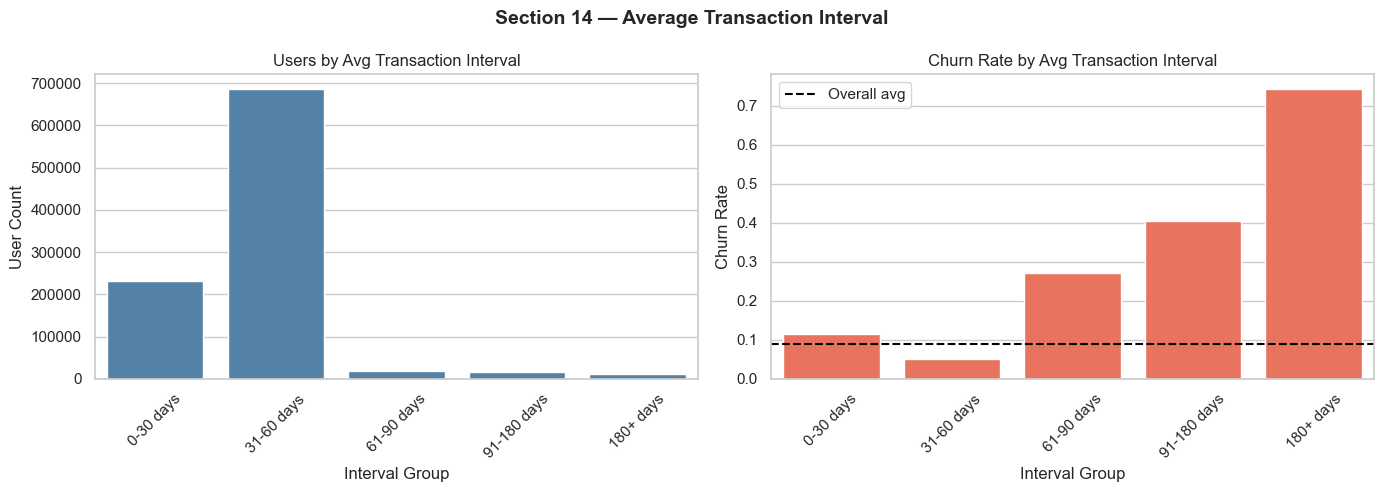

In [33]:
avg_interval = con.execute(f"""
    WITH txn_dates AS (
        SELECT
            msno,
            transaction_date,
            LAG(transaction_date) OVER (
                PARTITION BY msno
                ORDER BY transaction_date ASC
            ) AS prev_transaction_date
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
    ),
    user_interval AS (
        SELECT
            msno,
            AVG(DATEDIFF('day',
                STRPTIME(CAST(prev_transaction_date AS VARCHAR), '%Y%m%d'),
                STRPTIME(CAST(transaction_date AS VARCHAR), '%Y%m%d')
            )) AS avg_interval_days,
            COUNT(*) AS total_transactions
        FROM txn_dates
        WHERE prev_transaction_date IS NOT NULL
        GROUP BY msno
    )
    SELECT
        CASE
            WHEN avg_interval_days <= 30  THEN '0-30 days'
            WHEN avg_interval_days <= 60  THEN '31-60 days'
            WHEN avg_interval_days <= 90  THEN '61-90 days'
            WHEN avg_interval_days <= 180 THEN '91-180 days'
            ELSE '180+ days'
        END AS interval_group,
        COUNT(*) AS total_users,
        AVG(l.is_churn) AS churn_rate,
        AVG(avg_interval_days) AS avg_days
    FROM user_interval u
    JOIN '{PARQUET_DIR}train_v2.parquet' l
        ON u.msno = l.msno
    GROUP BY interval_group
    ORDER BY churn_rate DESC
""").df()

print(avg_interval)

order = ['0-30 days', '31-60 days', '61-90 days',
         '91-180 days', '180+ days']
interval_ordered = avg_interval.set_index('interval_group')\
                               .reindex(order).reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=interval_ordered, x='interval_group', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Avg Transaction Interval')
axes[0].set_xlabel('Interval Group')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=interval_ordered, x='interval_group', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Avg Transaction Interval')
axes[1].set_xlabel('Interval Group')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Section 14 — Average Transaction Interval',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== LAST MONTH CHURN HISTORY ===
   last_churn_status  total_users  churn_rate
0                  1         3632    0.916024
1                 -1       120803    0.305166
2                  0       846525    0.055684


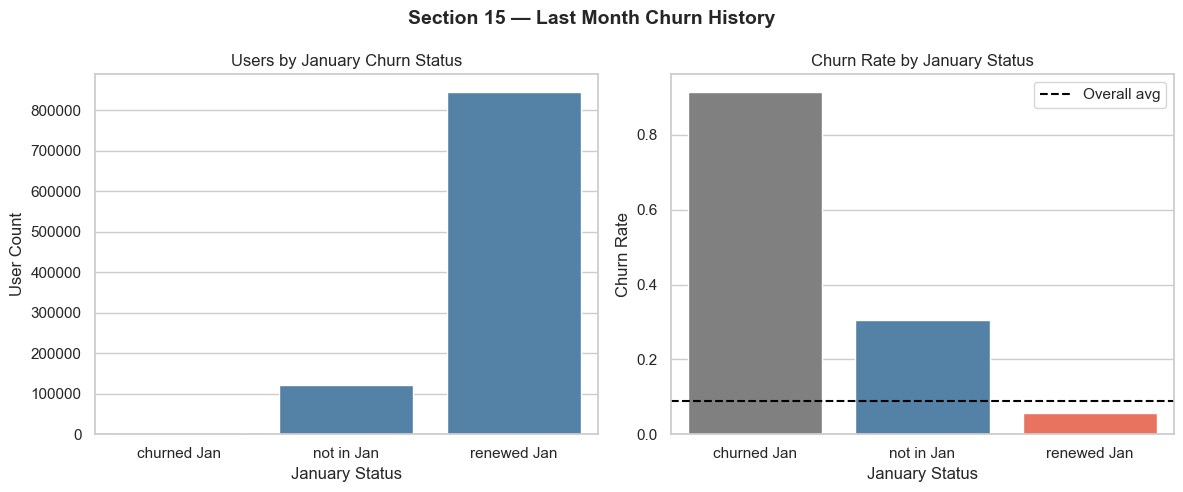

In [34]:
last_churn = con.execute(f"""
    WITH jan_labels AS (
        -- Generate January 2017 churn labels
        -- Users whose membership expired in January 2017
        WITH jan_expiry AS (
            SELECT DISTINCT msno
            FROM (
                SELECT * FROM '{PARQUET_DIR}transactions.parquet'
                UNION ALL
                SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
            )
            WHERE membership_expire_date BETWEEN 20170101 AND 20170131
        ),
        jan_renewed AS (
            SELECT DISTINCT msno
            FROM (
                SELECT * FROM '{PARQUET_DIR}transactions.parquet'
                UNION ALL
                SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
            )
            WHERE transaction_date BETWEEN 20170101 AND 20170228
            AND is_cancel = 0
        )
        SELECT
            e.msno,
            CASE WHEN r.msno IS NULL THEN 1 ELSE 0 END AS last_churn
        FROM jan_expiry e
        LEFT JOIN jan_renewed r ON e.msno = r.msno
    )
    SELECT
        COALESCE(j.last_churn, -1) AS last_churn_status,
        COUNT(*) AS total_users,
        AVG(t.is_churn) AS churn_rate
    FROM '{PARQUET_DIR}train_v2.parquet' t
    LEFT JOIN jan_labels j ON t.msno = j.msno
    GROUP BY last_churn_status
    ORDER BY churn_rate DESC
""").df()

print("=== LAST MONTH CHURN HISTORY ===")
print(last_churn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = {-1: 'not in Jan', 0: 'renewed Jan', 1: 'churned Jan'}
last_churn['label'] = last_churn['last_churn_status'].map(labels)

sns.barplot(data=last_churn, x='label', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by January Churn Status')
axes[0].set_xlabel('January Status')
axes[0].set_ylabel('User Count')

sns.barplot(data=last_churn, x='label', y='churn_rate',
            palette=['gray', 'steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Churn Rate by January Status')
axes[1].set_xlabel('January Status')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 15 — Last Month Churn History',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Users with transaction history: 970,949

=== CANCEL LAST 3 TRANSACTIONS ===
   cancel_last3  total_users  churn_rate
0           0.0       911765    0.062514
1           1.0        58548    0.510214
2           2.0          633    0.706161
3           3.0            3    1.000000

=== AUTO RENEW LAST 3 TRANSACTIONS ===
   autorenew_last3  total_users  churn_rate
0              0.0       107003    0.415474
1              1.0         6563    0.329118
2              2.0        32425    0.161203
3              3.0       824958    0.043003


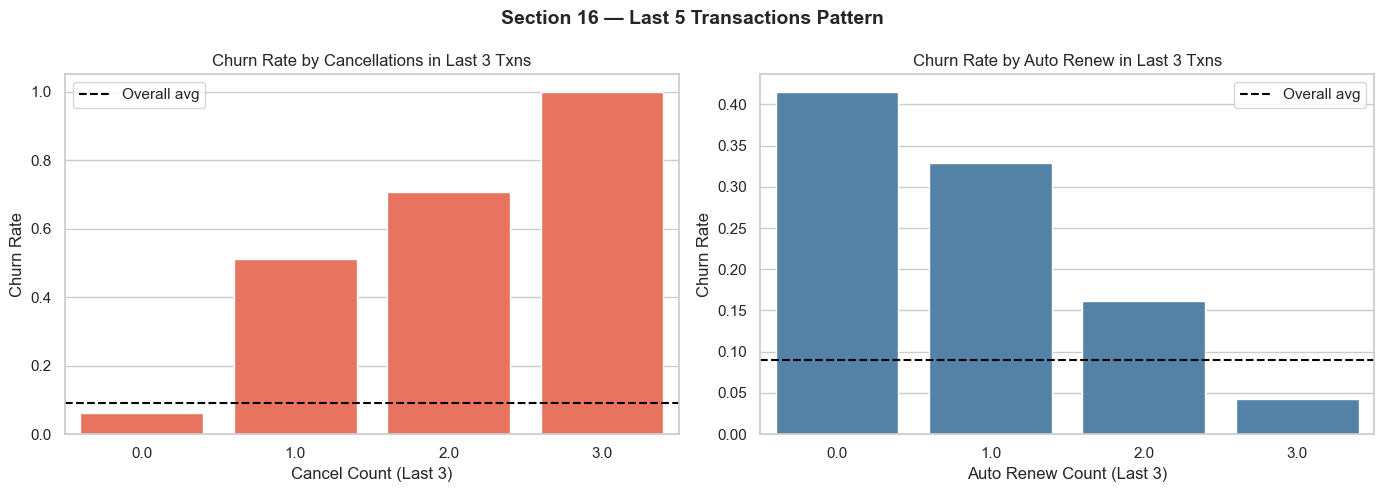

In [35]:
last5_churn = con.execute(f"""
    WITH ranked_txn AS (
        SELECT
            msno,
            is_cancel,
            is_auto_renew,
            actual_amount_paid,
            payment_plan_days,
            membership_expire_date,
            transaction_date,
            ROW_NUMBER() OVER (
                PARTITION BY msno
                ORDER BY transaction_date DESC
            ) AS rn
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
    )
    SELECT
        msno,
        -- Last transaction
        MAX(CASE WHEN rn=1 THEN is_cancel END)          AS t1_cancel,
        MAX(CASE WHEN rn=1 THEN is_auto_renew END)      AS t1_autorenew,
        MAX(CASE WHEN rn=1 THEN actual_amount_paid END) AS t1_amount,
        MAX(CASE WHEN rn=1 THEN payment_plan_days END)  AS t1_plan_days,
        -- 2nd last transaction
        MAX(CASE WHEN rn=2 THEN is_cancel END)          AS t2_cancel,
        MAX(CASE WHEN rn=2 THEN is_auto_renew END)      AS t2_autorenew,
        MAX(CASE WHEN rn=2 THEN actual_amount_paid END) AS t2_amount,
        -- 3rd last transaction
        MAX(CASE WHEN rn=3 THEN is_cancel END)          AS t3_cancel,
        MAX(CASE WHEN rn=3 THEN is_auto_renew END)      AS t3_autorenew,
        -- Cancel trend — are recent cancellations increasing?
        SUM(CASE WHEN rn <= 3 THEN is_cancel ELSE 0 END) AS cancel_last3,
        SUM(CASE WHEN rn <= 5 THEN is_cancel ELSE 0 END) AS cancel_last5,
        SUM(CASE WHEN rn <= 3 
            THEN is_auto_renew ELSE 0 END)              AS autorenew_last3,
        SUM(CASE WHEN rn <= 5 
            THEN is_auto_renew ELSE 0 END)              AS autorenew_last5
    FROM ranked_txn
    GROUP BY msno
""").df()

# Join with labels and analyze
last5_joined = last5_churn.merge(
    con.execute(f"""
        SELECT * FROM '{PARQUET_DIR}train_v2.parquet'
    """).df(),
    on='msno', how='inner'
)

print(f"Users with transaction history: {len(last5_joined):,}")

# Cancel trend analysis
cancel_trend = last5_joined.groupby('cancel_last3').agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print("\n=== CANCEL LAST 3 TRANSACTIONS ===")
print(cancel_trend)

# Auto renew trend
autorenew_trend = last5_joined.groupby('autorenew_last3').agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print("\n=== AUTO RENEW LAST 3 TRANSACTIONS ===")
print(autorenew_trend)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=cancel_trend, x='cancel_last3', y='churn_rate',
            color='tomato', ax=axes[0])
axes[0].set_title('Churn Rate by Cancellations in Last 3 Txns')
axes[0].set_xlabel('Cancel Count (Last 3)')
axes[0].set_ylabel('Churn Rate')
axes[0].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[0].legend()

sns.barplot(data=autorenew_trend, x='autorenew_last3', y='churn_rate',
            color='steelblue', ax=axes[1])
axes[1].set_title('Churn Rate by Auto Renew in Last 3 Txns')
axes[1].set_xlabel('Auto Renew Count (Last 3)')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()

plt.suptitle('Section 16 — Last 5 Transactions Pattern',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()